# Modelos Avanzados de Grafos


## Introducción

En esta tarea, se nos pide implementar el algoritmo Node2Vec para generar representaciones vectoriales de los nodos en un grafo. Node2Vec es una técnica de aprendizaje no supervisado que utiliza caminatas aleatorias para capturar la estructura del grafo y aprender representaciones de los nodos que pueden ser utilizadas para tareas como clasificación, clustering o visualización.



## Implementación de Node2Vec

Para implementar Node2Vec, seguiremos los siguientes pasos:
1. **Generar Caminatas Aleatorias**: Realizaremos caminatas aleatorias en el grafo para generar secuencias de nodos. Estas caminatas pueden ser controladas por dos parámetros, `p` y `q`, que determinan la probabilidad de regresar al nodo anterior o de explorar nuevos nodos.
2. **Entrenar un Modelo de Word2Vec**: Utilizaremos las secuencias de nodos generadas por las caminatas aleatorias para entrenar un modelo de Word2Vec, que aprenderá las representaciones vectoriales de los nodos.
3. **Obtener las Representaciones Vectoriales**: Una vez entrenado el modelo de Word2Vec, podremos obtener las representaciones vectoriales de los nodos en el grafo.


### Paso 0: Configuración y Carga de Datos

Importamos las librerías necesarias y cargamos el dataset de Cora.


In [2]:

import pandas as pd
import networkx as nx
from node2vec import Node2Vec

from pathlib import Path

# Directorio base del proyecto
BASE_DIR = Path.cwd().parent


# Rutas al dataset
data_path = BASE_DIR / "data" / "cora"
path_cora_content = data_path / "cora.content"
path_cora_cites = data_path / "cora.cites"

# 1. Reconstruir el grafo G y recuperar los ID's de los nodos.
cora_cites = pd.read_csv(path_cora_cites, sep='\t', header=None, names=['cited_paper_id', 'citing_paper_id'])
cora_cites = cora_cites.astype(str)
G = nx.from_pandas_edgelist(cora_cites, source='cited_paper_id', target='citing_paper_id')

# carga también las etiquetas (labels) y los paper_ids
cora_content = pd.read_csv(path_cora_content, sep='\t', header=None)
paper_ids = cora_content[0].astype(str).tolist()
labels = cora_content[1434].tolist()  # La última columna contiene las etiquetas




c:\Users\juana\aprendizaje-automatico-relacional\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Paso 1: Entranamiento de Node2Vec

El algoritmo de Node2Vec funciona simulando "caminos aleatorios" (random walks) a través del grafo. Poedmos verlo como un caminante ciego que salta de artículo en artículo a través de las citas. Luego, el algoritmo aprende a representar los nodos que aparecen frecuentemente en los mismos caminos con vectores numéricos similares.

In [3]:
# 2. Inicializar Node2Vec
# parameters:
# dimensions: El tamaño del vector latente resultante (ej. 64 variables en lugar de 1433)
# walk_length: Cuántos saltos da el caminante en cada ruta
# num_walks: Cuántas rutas distintas inicia desde cada nodo
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4, seed=42)

# 3. Entrenar el modelo (Aprender las representaciones latentes)
print("Entrenando el modelo Node2Vec (esto puede tardar unos minutos)...")
modelo_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)

# 4. Extraer los embeddings (vectores) en el mismo orden que nuestros paper_ids
embeddings = [modelo_n2v.wv[nodo] for nodo in paper_ids]

# 5. Crear nuestro nuevo conjunto de entrada X
X_node2vec = pd.DataFrame(embeddings, index=paper_ids)
X_node2vec.index.name = "paper_id"

print(f"Nueva matriz X generada por Node2Vec: {X_node2vec.shape}")

Computing transition probabilities: 100%|██████████| 2708/2708 [00:00<00:00, 5908.56it/s]


Entrenando el modelo Node2Vec (esto puede tardar unos minutos)...
Nueva matriz X generada por Node2Vec: (2708, 64)


### Paso 2: Clasificación sobre los embeddings de Node2Vec

Con `X_node2vec` lista, aplicamos exactamente la misma tubería de Scikit-Learn que en la Tarea 2.1:

1. Construir `y` y partir train/test con estratificación.
2. Entrenar los 4 modelos base con búsqueda de hiperparámetros por validación cruzada.
3. Evaluar en test con F1-macro.
4. Comparar contra el baseline de características manuales.

In [4]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Construir la variable objetivo y alineada con X_node2vec
y = pd.Series(labels, index=paper_ids, name="class_label")

# Partición estratificada 80/20 — mismos parámetros que Tarea 2.1
X_train, X_test, y_train, y_test = train_test_split(
    X_node2vec,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_node2vec shape: {X_node2vec.shape}")
print(f"Train shape: {X_train.shape}  |  Test shape: {X_test.shape}")
print("\nDistribución de clases en train (proporciones):")
print(y_train.value_counts(normalize=True).round(3))

X_node2vec shape: (2708, 64)
Train shape: (2166, 64)  |  Test shape: (542, 64)

Distribución de clases en train (proporciones):
class_label
Neural_Networks           0.302
Probabilistic_Methods     0.157
Genetic_Algorithms        0.154
Theory                    0.130
Case_Based                0.110
Reinforcement_Learning    0.080
Rule_Learning             0.066
Name: proportion, dtype: float64


### Paso 3: Definición de modelos y búsqueda de hiperparámetros

Mismos 4 pipelines y grids que en la Tarea 2.1. Se usa `GridSearchCV` con `StratifiedKFold` de 5 pliegues y `f1_macro` como métrica de selección para que la comparativa sea controlada y justa.

In [5]:
modelos = {
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier()),
    ]),
    "ArbolDecision": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "NaiveBayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(max_iter=300, early_stopping=False, random_state=RANDOM_STATE)),
    ]),
}

grids = {
    "kNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    "ArbolDecision": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
    },
    "NaiveBayes": {
        "clf__var_smoothing": np.logspace(-11, -7, 5),
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "clf__alpha": [1e-4, 1e-3],
        "clf__learning_rate_init": [1e-3, 1e-2],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mejores_modelos = {}
resumen_busqueda = []

for nombre, pipeline in modelos.items():
    print(f"Entrenando {nombre}...")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grids[nombre],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    mejores_modelos[nombre] = search.best_estimator_
    resumen_busqueda.append({
        "modelo": nombre,
        "best_cv_f1_macro": round(search.best_score_, 4),
        "best_params": search.best_params_,
    })
    print(f"  -> best CV F1-macro: {search.best_score_:.4f}")

resumen_cv_n2v = pd.DataFrame(resumen_busqueda).sort_values("best_cv_f1_macro", ascending=False)
display(resumen_cv_n2v[["modelo", "best_cv_f1_macro"]])

Entrenando kNN...
  -> best CV F1-macro: 0.8388
Entrenando ArbolDecision...
  -> best CV F1-macro: 0.6845
Entrenando NaiveBayes...
  -> best CV F1-macro: 0.7765
Entrenando MLP...
  -> best CV F1-macro: 0.8389


,modelo,best_cv_f1_macro
3,MLP,0.8389
0,kNN,0.8388
2,NaiveBayes,0.7765
1,ArbolDecision,0.6845


### Paso 4: Evaluación final en el conjunto de prueba

Resultados en test (Node2Vec — 64 features):


,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,kNN,0.880,0.866,0.876,0.870
3,MLP,0.863,0.852,0.858,0.853
2,NaiveBayes,0.766,0.749,0.774,0.758
1,ArbolDecision,0.736,0.714,0.717,0.714



Mejor modelo: kNN

Reporte por clase:
                        precision    recall  f1-score   support

            Case_Based       0.85      0.92      0.88        60
    Genetic_Algorithms       0.98      0.99      0.98        84
       Neural_Networks       0.89      0.87      0.88       164
 Probabilistic_Methods       0.89      0.86      0.87        85
Reinforcement_Learning       0.80      0.91      0.85        43
         Rule_Learning       0.83      0.81      0.82        36
                Theory       0.83      0.79      0.81        70

              accuracy                           0.88       542
             macro avg       0.87      0.88      0.87       542
          weighted avg       0.88      0.88      0.88       542



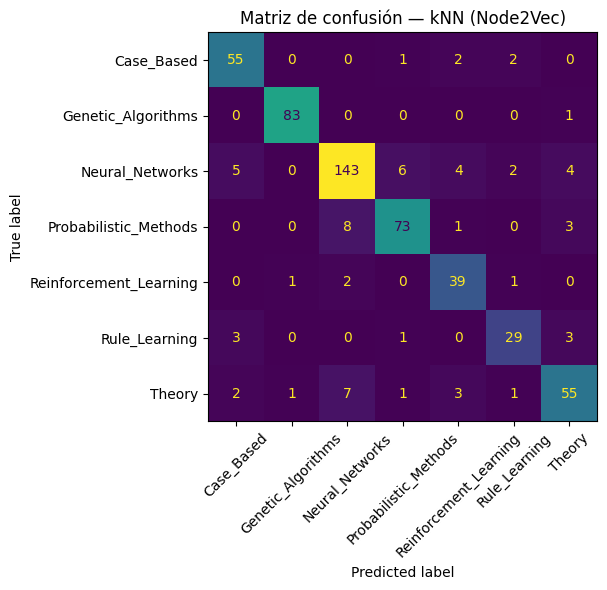

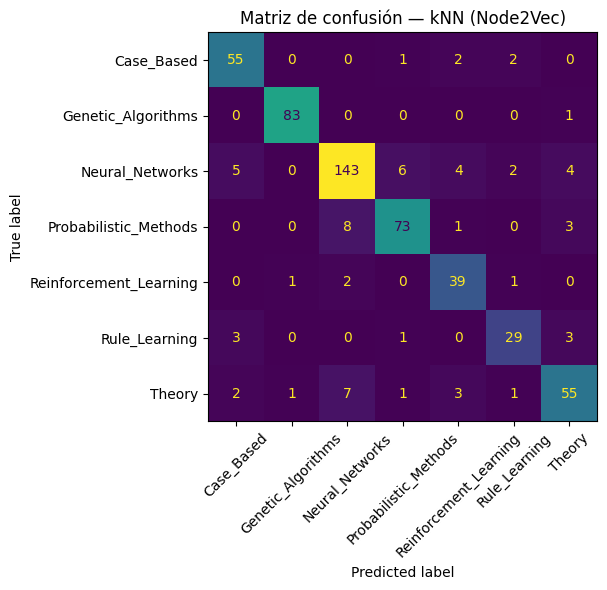


Figura guardada en: c:\Users\juana\aprendizaje-automatico-relacional\docs\trabajo\figuras\matriz_confusion_kNN_Node2Vec.png


In [6]:
resultados_test = []
reportes_clase = {}
matrices_confusion = {}

for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    resultados_test.append({
        "modelo": nombre,
        "accuracy": round(accuracy, 3),
        "precision_macro": round(precision, 3),
        "recall_macro": round(recall, 3),
        "f1_macro": round(f1_macro, 3),
    })
    reportes_clase[nombre] = classification_report(y_test, y_pred, zero_division=0)
    matrices_confusion[nombre] = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

resumen_test_n2v = pd.DataFrame(resultados_test).sort_values("f1_macro", ascending=False)
print("Resultados en test (Node2Vec — 64 features):")
display(resumen_test_n2v)

# Reporte y matriz de confusión del mejor modelo
mejor_nombre = resumen_test_n2v.iloc[0]["modelo"]
print(f"\nMejor modelo: {mejor_nombre}")
print(f"\nReporte por clase:\n{reportes_clase[mejor_nombre]}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matrices_confusion[mejor_nombre],
    display_labels=np.unique(y_test),
).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión — {mejor_nombre} (Node2Vec)")
plt.tight_layout()
plt.show()

# Guardar explícitamente la matriz de confusión de kNN para el informe LaTeX
if "kNN" in mejores_modelos:
    y_pred_knn = mejores_modelos["kNN"].predict(X_test)
    cm_knn = confusion_matrix(y_test, y_pred_knn, labels=np.unique(y_test))

    fig_knn, ax_knn = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(
        confusion_matrix=cm_knn,
        display_labels=np.unique(y_test),
    ).plot(ax=ax_knn, xticks_rotation=45, colorbar=False)
    ax_knn.set_title("Matriz de confusión — kNN (Node2Vec)")
    plt.tight_layout()

    figuras_dir = BASE_DIR / "docs" / "trabajo" / "figuras"
    figuras_dir.mkdir(parents=True, exist_ok=True)
    salida_figura = figuras_dir / "matriz_confusion_kNN_Node2Vec.png"
    fig_knn.savefig(salida_figura, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\nFigura guardada en: {salida_figura}")
else:
    print("\nNo se encontró el modelo kNN en 'mejores_modelos'.")

### Paso 5: Tabla comparativa — Características manuales vs. Node2Vec

Comparamos los resultados de ambas estrategias de representación. El baseline de la Tarea 2.1 usa **1437 features** (1433 texto + 4 topológicas); Node2Vec comprime toda la información estructural en **64 dimensiones** densas aprendidas automáticamente.

In [7]:
# Resultados baseline de la Tarea 2.1 (features manuales: 1433 texto + 4 topológicas)
baseline_tarea21 = pd.DataFrame([
    {"modelo": "Árbol de Decisión", "accuracy": 0.771, "f1_macro": 0.758, "precision_macro": 0.762, "recall_macro": 0.760},
    {"modelo": "MLP",               "accuracy": 0.730, "f1_macro": 0.717, "precision_macro": 0.721, "recall_macro": 0.717},
    {"modelo": "Naive Bayes",        "accuracy": 0.452, "f1_macro": 0.428, "precision_macro": 0.437, "recall_macro": 0.422},
    {"modelo": "kNN",                "accuracy": 0.422, "f1_macro": 0.416, "precision_macro": 0.469, "recall_macro": 0.406},
])
baseline_tarea21["estrategia"] = "Manual (1437 features)"

# Resultados actuales con Node2Vec
nombre_map = {"ArbolDecision": "Árbol de Decisión", "NaiveBayes": "Naive Bayes", "kNN": "kNN", "MLP": "MLP"}
n2v_resultados = resumen_test_n2v.copy()
n2v_resultados["modelo"] = n2v_resultados["modelo"].map(nombre_map)
n2v_resultados["estrategia"] = "Node2Vec (64 features)"

# Tabla comparativa unificada — F1-macro por modelo y estrategia
comparativa = pd.concat(
    [
        baseline_tarea21,
        n2v_resultados[["modelo", "accuracy", "f1_macro", "precision_macro", "recall_macro", "estrategia"]],
    ],
    ignore_index=True,
)

pivot = comparativa.pivot_table(
    index="modelo",
    columns="estrategia",
    values="f1_macro",
).round(3)

print("=== F1-macro: Características manuales vs. Node2Vec ===\n")
display(pivot)

# Resumen ejecutivo
mejor_n2v = resumen_test_n2v.iloc[0]
mejor_n2v_nombre = nombre_map.get(mejor_n2v["modelo"], mejor_n2v["modelo"])
print(f"\nMejor modelo Node2Vec : {mejor_n2v_nombre} — F1-macro = {mejor_n2v['f1_macro']:.3f}")
print(f"Mejor modelo manual   : Árbol de Decisión   — F1-macro = 0.758")
delta = mejor_n2v["f1_macro"] - 0.758
signo = "+" if delta >= 0 else ""
print(f"Diferencia            : {signo}{delta:.3f}")

=== F1-macro: Características manuales vs. Node2Vec ===



estrategia,Manual (1437 features),Node2Vec (64 features)
modelo,,
MLP,0.717,0.853
Naive Bayes,0.428,0.758
kNN,0.416,0.870
Árbol de Decisión,0.758,0.714



Mejor modelo Node2Vec : kNN — F1-macro = 0.870
Mejor modelo manual   : Árbol de Decisión   — F1-macro = 0.758
Diferencia            : +0.112
